In [103]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

In [104]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [105]:
train_path = "dataset/train"
valid_path = "dataset/validation"
test_path = "dataset/test"

In [106]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    shuffle=False,
    class_mode='categorical'
)

Found 232 images belonging to 4 classes.
Found 49 images belonging to 4 classes.
Found 51 images belonging to 4 classes.


In [107]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\RAJEET\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [108]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [109]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
2/8 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2578 - loss: 1.7886

c:\Users\RAJEET\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.2974 - loss: 1.6112 - val_accuracy: 0.3061 - val_loss: 1.3216 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.3233 - loss: 1.3266 - val_accuracy: 0.4286 - val_loss: 1.2830 - learning_rate: 0.0010
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.3750 - loss: 1.3188 - val_accuracy: 0.3265 - val_loss: 1.2603 - learning_rate: 0.0010
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.3491 - loss: 1.3161 - val_accuracy: 0.5510 - val_loss: 1.2387 - learning_rate: 0.0010
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4440 - loss: 1.2248 - val_accuracy: 0.3878 - val_loss: 1.1899 - learning_rate: 0.0010
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5259 - loss: 1.1201 - val_accuracy: 0.5510 - val_loss: 1.1644 - learning_rate: 0.0010
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5733 - loss: 1.0559 - val_accuracy: 0.4898 - val_loss: 1.1213

In [110]:
model.save("vehicle_model.h5")

In [111]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6078 - loss: 0.9911
Test Accuracy: 0.6078431606292725


In [112]:
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

labels = list(test_generator.class_indices.keys())

print("\nClassification Report\n")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=labels
))

print("\nConfusion Matrix\n")

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step

Classification Report

              precision    recall  f1-score   support

         Bus       0.00      0.00      0.00         6
         Car       0.52      0.73      0.61        15
       Truck       0.53      0.53      0.53        15
  motorcycle       0.80      0.80      0.80        15

    accuracy                           0.61        51
   macro avg       0.46      0.52      0.49        51
weighted avg       0.55      0.61      0.57        51


Confusion Matrix

[[ 0  3  2  1]
 [ 0 11  4  0]
 [ 0  5  8  2]
 [ 0  2  1 12]]


c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


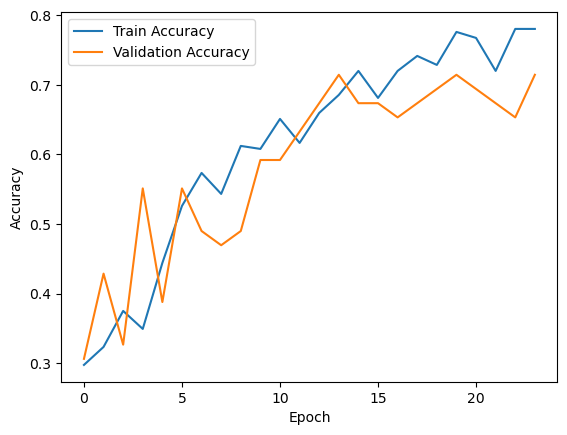

In [113]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

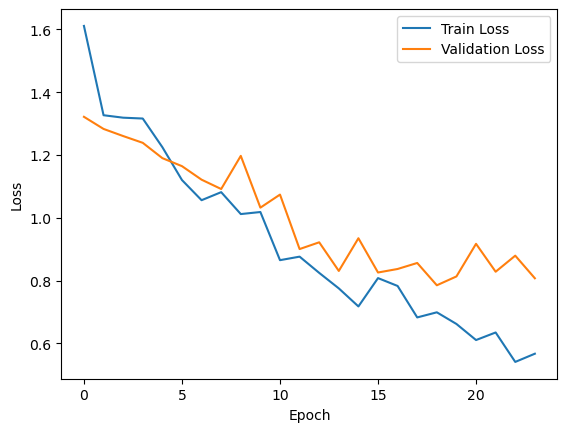

In [114]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [115]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6078 - loss: 0.9911
Test Accuracy: 0.6078431606292725


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


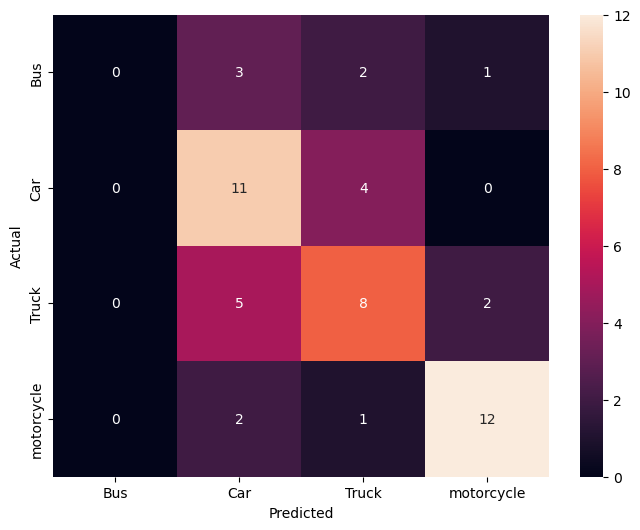

In [116]:
import seaborn as sns
pred = model.predict(test_generator)

predicted_classes = np.argmax(pred,axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(true_classes,predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [117]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

         Bus       0.00      0.00      0.00         6
         Car       0.52      0.73      0.61        15
       Truck       0.53      0.53      0.53        15
  motorcycle       0.80      0.80      0.80        15

    accuracy                           0.61        51
   macro avg       0.46      0.52      0.49        51
weighted avg       0.55      0.61      0.57        51



c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAJEET\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [125]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

In [126]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to the image
img_path ="test\Car\Image_11.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Class names
class_names = list(train_generator.class_indices.keys())

# Predicted class
predicted_class = class_names[np.argmax(prediction)]

# Confidence
confidence = np.max(prediction) * 100

print(f"Predicted Vehicle: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'test\\Car\\Image_11.jpg'